In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from PIL import Image


# Load your combined Visium data
adata = sc.read_h5ad("./TN_MIBC_4_samples/GSE171351_combined_visium.h5ad")

# Inspect the object
print(adata)
print(adata.obs.head())
print(adata.obsm.keys())


Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check

# Define folder where your images are located
img_folder = "./TN_MIBC_4_samples/"

# Map library IDs to image filenames
image_files = {
    "A1": "GSM5224027_A1.jpg",
    "B1": "GSM5224028_B1.jpg",
    "C1": "GSM5224029_C1.jpg",
    "D1": "GSM5224030_D1.jpg"
}

for lib_id, filename in image_files.items():
    img_path = os.path.join(img_folder, filename)
    if not os.path.exists(img_path):
        print(f"Warning: {img_path} not found!")
        continue

    # Load the image
    img = imread(img_path)
    orig_height, orig_width = img.shape[:2]


    # Attach resized image to AnnData
    if 'spatial' not in adata.uns:
        adata.uns['spatial'] = {}
    if lib_id not in adata.uns['spatial']:
        adata.uns['spatial'][lib_id] = {}

    adata.uns['spatial'][lib_id]['images'] = {'hires': img}


# Save updated AnnData
adata.write_h5ad("GSE171351_combined_visium_with_images.h5ad")
print("Images attached, coordinates rescaled, and AnnData saved.")

/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` in

AnnData object with n_obs × n_vars = 4086 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sampleID', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
                          in_tissue  array_row  array_col sampleID  \
AAACCGTTCGTCCAGG-1-0-0-0          1         52         42       A1   
AAACGAGACGGTTGAT-1-0-0-0          1         35         79       A1   
AAACTGCTGGCTCCAA-1-0-0-0          1         45         67       A1   
AAAGGCTACGGACCAT-1-0-0-0          1         62         54       A1   
AAAGGCTCTCGCGCCG-1-0-0-0          1 

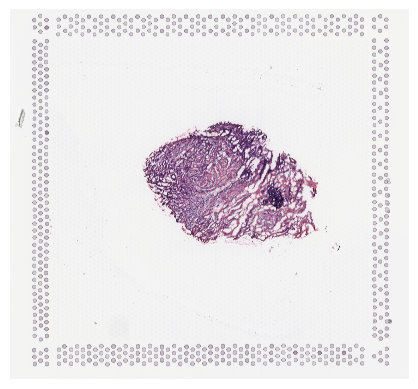

In [2]:
##checking image attaching works
import matplotlib.pyplot as plt

plt.imshow(adata.uns['spatial']['A1']['images']['hires'])
plt.axis('off')
plt.show()


In [3]:
#Hutch tutorial -> https://rawcdn.githack.com/FredHutch/visium-toy/refs/heads/main/toy-visium.html

# Inspect available images and scalefactors
library_id = list(adata.uns['spatial'].keys())[0]
adata.uns['spatial'][library_id]['scalefactors']




{'fiducial_diameter_fullres': np.float64(215.00227566175283),
 'spot_diameter_fullres': np.float64(133.09664683822794),
 'tissue_hires_scalef': np.float64(0.114311844),
 'tissue_lowres_scalef': np.float64(0.03429355)}

Plotting library: A1


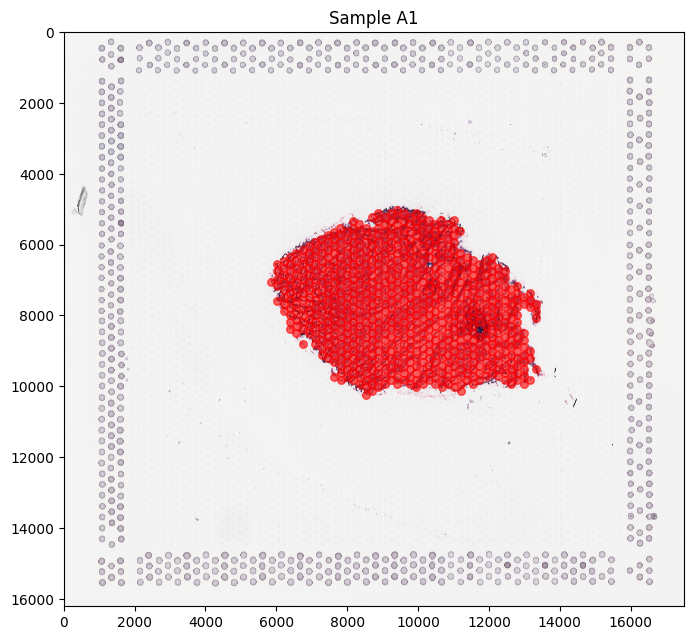

In [4]:
import matplotlib.pyplot as plt

# Pick one Visium sample (library)
library_id = list(adata.uns['spatial'].keys())[0]
print("Plotting library:", library_id)

# Subset only that sample
adata_sub = adata[adata.obs['sampleID'] == library_id].copy()

# Get the matching image and coordinates
img = adata.uns['spatial'][library_id]['images']['hires']
coords = adata_sub.obsm['spatial']

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.scatter(coords[:, 0], coords[:, 1],
           s=30, c='red', alpha=0.6)
ax.set_title(f"Sample {library_id}")
plt.show()


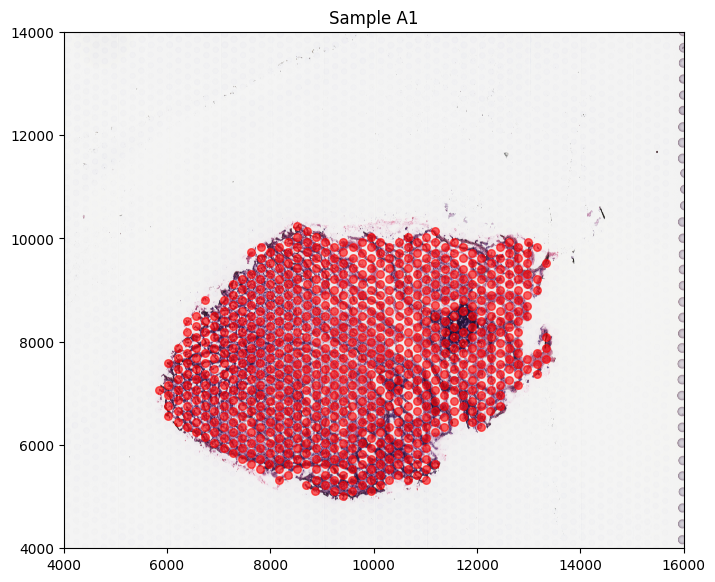

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.scatter(coords[:, 0], coords[:, 1], s=30, c='red', alpha=0.6)
ax.set_title(f"Sample {library_id}")

# Zoom in — adjust these ranges as you like
ax.set_xlim(4000, 16000)   # smaller range = more zoom
ax.set_ylim(4000, 14000)   # reversed for correct image orientation

plt.show()


In [ ]:
for lib_id in adata.uns['spatial'].keys():
    #subset
    # Subset only that sample
    adata_sub = adata[adata.obs['sampleID'] == lib_id].copy()

    # Get the matching image and coordinates
    img = adata.uns['spatial'][lib_id]['images']['hires']
    coords = adata_sub.obsm['spatial']

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.scatter(coords[:, 0], coords[:, 1],
            s=30, c='red', alpha=0.6)
    ax.set_title(f"Sample {lib_id}")
    
    # Zoom in — adjust these ranges as you like
    ax.set_xlim(4000, 16000)   # smaller range = more zoom
    ax.set_ylim(2000, 14000)   # reversed for correct image orientation
    plt.show()      

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gene = "FOXA1"  # change this to any gene in adata.var_names

for lib_id in adata.uns['spatial'].keys():
    # Subset only that sample
    adata_sub = adata[adata.obs['sampleID'] == lib_id].copy()

    # Get image and coordinates
    img = adata.uns['spatial'][lib_id]['images']['hires']
    coords = adata_sub.obsm['spatial']

    # Extract gene expression vector
    if gene not in adata_sub.var_names:
        print(f"⚠️ Gene {gene} not found in {lib_id}")
        continue
    gene_expr = adata_sub[:, gene].X
    # convert sparse matrix to dense array if needed
    if hasattr(gene_expr, "toarray"):
        gene_expr = gene_expr.toarray().flatten()
    else:
        gene_expr = np.ravel(gene_expr)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)

    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=gene_expr, cmap="viridis", s=30, alpha=0.5)
    ax.set_title(f"{gene} expression — {lib_id}")
    ax.set_xlim(4000, 16000)
    ax.set_ylim(2000, 14000)
    plt.colorbar(sc, ax=ax, label=f"{gene} expression")
    plt.show()


In [8]:
print(adata)
print("Layers:", list(adata.layers.keys()) if hasattr(adata, "layers") else "No layers")
print("Has .raw:", adata.raw is not None)


AnnData object with n_obs × n_vars = 4086 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sampleID', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
Layers: []
Has .raw: False


In [9]:
import scanpy as sc
import squidpy as sq

sc.pp.normalize_total(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata_vis = adata[:, adata.var.highly_variable]

sc.pp.pca(adata_vis)
sc.pp.neighbors(adata_vis)
sc.tl.leiden(adata_vis, resolution=0.6)
sc.tl.rank_genes_groups(adata_vis, 'leiden', method='wilcoxon')

# inspect top marker genes per cluster
sc.pl.rank_genes_groups(adata_vis, n_genes=6, sharey=False)

# visualize clusters in space
sq.pl.spatial_scatter(adata_vis, color='leiden', library_key='sampleID')

# Choose how many top genes to display per cluster
n_genes = 6

# Extract top marker names
top_genes = []
for cluster in adata_vis.obs['leiden'].cat.categories:
    genes = adata_vis.uns['rank_genes_groups']['names'][cluster][:n_genes]
    top_genes.extend(genes)

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))

import scanpy as sc
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

heatmap = sc.pl.heatmap(
    adata_vis,
    var_names=top_genes,
    groupby='leiden',
    cmap='viridis',
    standard_scale='var',
    show_gene_labels=True,
    dendrogram=False,
    show=False  # don't auto-display,
)

# Rotate x-axis labels (gene names)
for ax in heatmap.values():
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=12)

plt.show()



/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/scipy/sparse/_data.py:144: RuntimeWarning: overflow encountered in expm1
  result = op(self._deduped_data())
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:328: RuntimeWarning: overflow encountered in expm1
  x = np.expm1(x)


ValueError: cannot specify integer `bins` when input data contains infinity

Processing library: A1


/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


Plotting clusters for A1...
Processing library: B1


/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


Plotting clusters for B1...
Processing library: C1


/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


Plotting clusters for C1...
Processing library: D1


KeyboardInterrupt: 

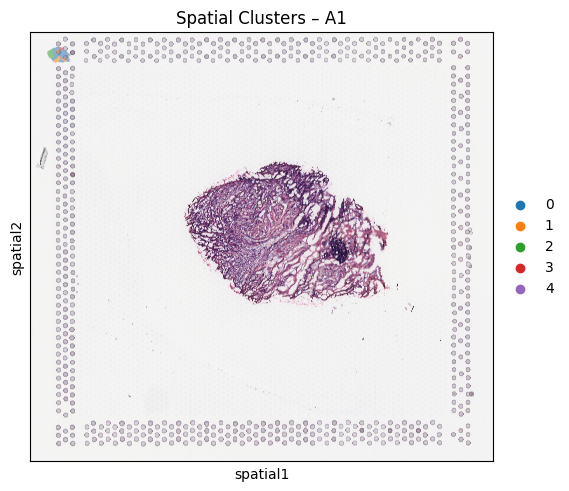

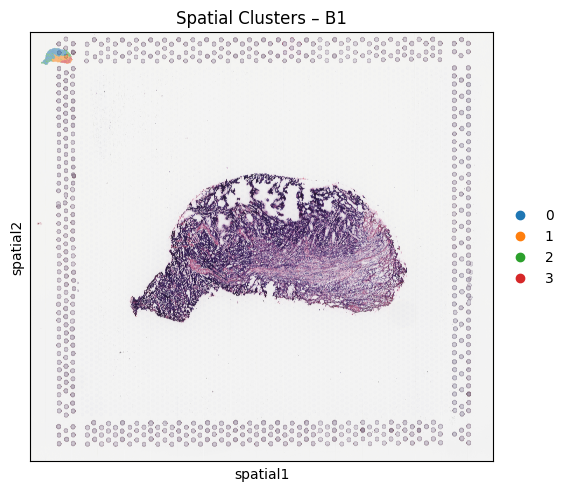

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

# List all library IDs (Visium slides)
library_ids = list(adata.obs['sampleID'].unique())

for lib_id in library_ids:
    print(f"Processing library: {lib_id}")
    
    # Subset AnnData for this slide
    adata_sub = adata[adata.obs['sampleID'] == lib_id].copy()

    # Normalize, select HVGs, and cluster
    sc.pp.normalize_total(adata_sub)
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=3000)
    adata_sub = adata_sub[:, adata_sub.var.highly_variable]
    
    sc.pp.pca(adata_sub)
    sc.pp.neighbors(adata_sub)
    sc.tl.leiden(adata_sub, resolution=0.6)
    
    # Store results back into main object (optional)
    adata.obs.loc[adata_sub.obs_names, 'leiden_' + lib_id] = adata_sub.obs['leiden']

    # Plot spatial clusters
    print(f"Plotting clusters for {lib_id}...")
    sq.pl.spatial_scatter(
        adata_sub,
        color='leiden',
        library_id=lib_id,
        title=f"Spatial Clusters – {lib_id}",
        size=1.3
    )

plt.show()


In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# List all Visium library IDs
library_ids = list(adata.obs['sampleID'].unique())

for lib_id in library_ids:
    print(f"Processing library: {lib_id}")
    
    # Subset for that slide
    adata_sub = adata[adata.obs['sampleID'] == lib_id].copy()

    # Normalize, HVGs, PCA, clustering
    sc.pp.normalize_total(adata_sub)
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=3000)
    adata_sub = adata_sub[:, adata_sub.var.highly_variable]
    sc.pp.pca(adata_sub)
    sc.pp.neighbors(adata_sub)
    sc.tl.leiden(adata_sub, resolution=0.6)

    # Get spatial data
    img = adata.uns['spatial'][lib_id]['images']['hires']
    coords = adata_sub.obsm['spatial']

    # Get cluster labels
    clusters = adata_sub.obs['leiden'].astype(str)

    # Generate colors for clusters
    unique_clusters = sorted(clusters.unique())
    cluster_colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
    color_map = dict(zip(unique_clusters, cluster_colors))
    spot_colors = clusters.map(color_map)

    # Plot overlay
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    sc_plot = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=spot_colors,
        s=25,
        alpha=0.7,
        edgecolor='none'
    )
    ax.set_title(f"Spatial Clusters — {lib_id}", fontsize=14)
    ax.set_xlim(4000, 16000)  # same limits you used for your gene plots
    ax.set_ylim(2000, 14000)
    ax.invert_yaxis()  # keep correct orientation
    plt.show()


NameError: name 'adata' is not defined